In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
class PoissonProcess:

    def __init__(self, lam):

        self.lam = lam

    def simulate(self, t):

       raise  NotImplementedError("Debes implementar el metodo en clase hija")


    def plot(self, t, color="blue", linestyle="-", marker=None):

        # Simulamos una trayectoria
        S, N = self.simulate(t)

        # Gráfica tipo escalón (propia de procesos de conteo)
        plt.figure()
        plt.step(S, N, where="post",
                 color=color,
                 linestyle=linestyle,
                 marker=marker)

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()

In [13]:
class PoissonProcess1(PoissonProcess):


    def __init__(self, lam):

       super().__init__(lam)
       self.expo = torch.distributions.Exponential(self.lam)


    def simulate(self, t):

        time = 0          # tiempo actual del proceso
        S = []            # lista de tiempos de llegada

        while True:

            # Generamos un tiempo entre llegadas ~ Exp(λ)
            T = self.expo.sample().item()

            # Actualizamos el tiempo acumulado
            time += T

            # Si excede el horizonte t, terminamos
            if time > t:
                break

            # Guardamos el tiempo de llegada
            S.append(time)

        # Convertimos a tensor
        S = torch.tensor(S)


        # Número de eventos
        n = len(S)

        N = torch.arange(0, n + 1)
        N = torch.cat((N, torch.tensor([n])))

        S = torch.cat((torch.tensor([0.0]), S, torch.tensor([t])))

        return S, N


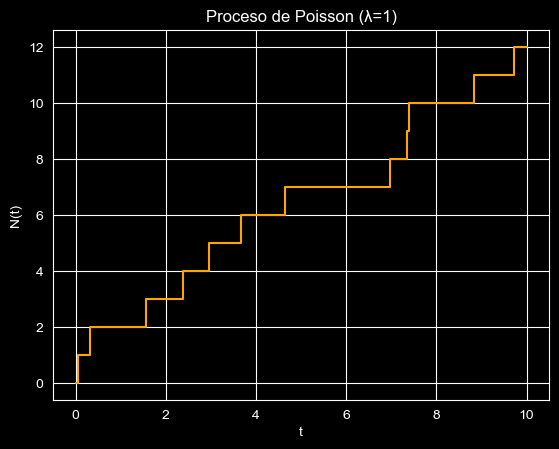

In [14]:
poi_p = PoissonProcess1(1)
poi_p.plot(10,color='orange',linestyle="-")

In [15]:
# noinspection PyMethodOverriding
class PoissonProcess2(PoissonProcess):

    def simulate(self, t, n):


        # Malla uniforme de tiempos
        S = torch.linspace(0, t, n + 1)

        # Vector para almacenar el proceso
        N = torch.zeros(n + 1)

        # Longitud de cada intervalo
        delta = t / n  

        # Simulación de incrementos independientes
        for i in range(1, n + 1):

            # Incremento ~ Poisson(λ Δt)
            X = torch.distributions.Poisson(self.lam * delta).sample()
            
            # Propiedad de incrementos independientes
            N[i] = N[i - 1] + X

        return S, N

    def plot(self, t, n, color="blue", linestyle="-", marker=None):

        # Simulamos una trayectoria
        S, N = self.simulate(t,n)

        # Gráfica tipo escalón (propia de procesos de conteo)
        plt.figure()
        plt.step(S, N, where="post",
                 color=color,
                 linestyle=linestyle,
                 marker=marker)

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()


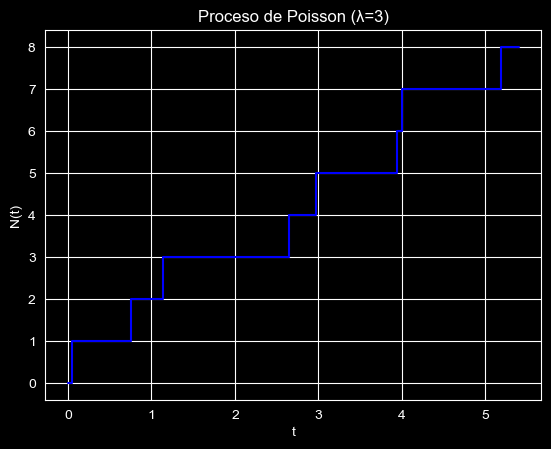

In [19]:
poi_p2 = PoissonProcess2(3)
poi_p2.plot(5.4,100)

In [28]:
class PoissonProcess3(PoissonProcess):

    def simulate(self, t):

        # Paso 1: número total de saltos
        # N ~ Poisson(λ tf)
        n = int(torch.distributions.Poisson(self.lam * t).sample().item())

        # Paso 2: tiempos de llegada sin ordenar
        # Uniformes en [0, tf]
        U = torch.rand(n) * t

        # Paso 3: ordenar tiempos
        S = torch.sort(U).values
        S = torch.cat((torch.tensor([0.0]), S, torch.tensor([t])))

        N = torch.arange(0, n + 1)
        N = torch.cat((N, torch.tensor([n])))

        return S, N

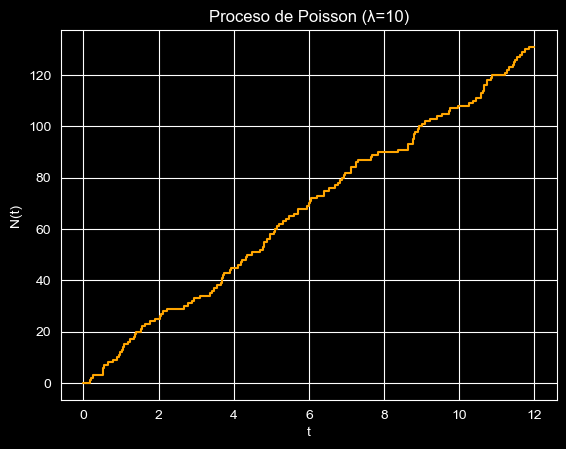

In [29]:
pp3 = PoissonProcess3(10)
pp3.plot(12,color="orange")

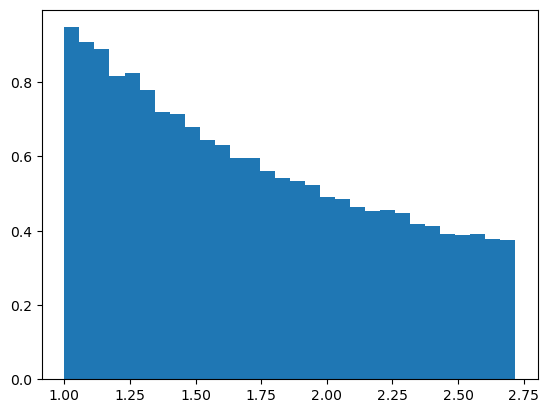